In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

2025-10-20 09:43:20.071083: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(array([[[[186.       , 178.       , 159.       ],
          [185.99777  , 177.99777  , 158.99777  ],
          [185.66295  , 177.66295  , 158.66295  ],
          ...,
          [174.64064  , 166.30359  , 147.97769  ],
          [176.9844   , 168.98218  , 149.98663  ],
          [177.       , 169.       , 150.       ]],
 
         [[185.9933   , 177.9933   , 158.9933   ],
          [185.99107  , 177.99107  , 158.99107  ],
          [185.657    , 177.657    , 158.657    ],
          ...,
          [174.68233  , 166.34825  , 148.02086  ],
          [177.0246   , 169.0246   , 150.02905  ],
          [177.04018  , 169.0424   , 150.0424   ]],
 
         [[184.98885  , 176.98885  , 157.98885  ],
          [184.98737  , 176.98737  , 157.98737  ],
          [184.7654   , 176.7654   , 157.7654   ],
          ...,
          [180.93481  , 173.04842  , 154.49532  ],
          [183.05287  , 175.38844  , 156.3914   ],
          [183.06697  , 175.40402  , 156.40402  ]],
 
         ...,
 
         [[1

In [3]:
# 分類名（no／yes）をリストとして格納する
class_names = train_dataset.class_names
class_names

['cat', 'dog']

2025-10-20 09:44:53.421455: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


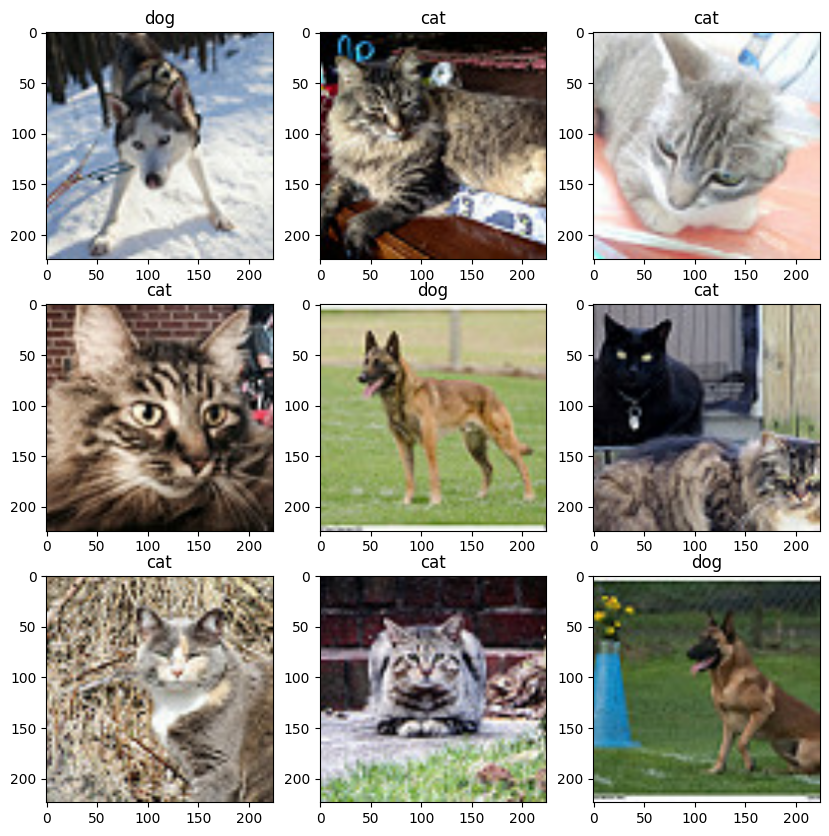

In [4]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [5]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [6]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [7]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [8]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

2025-10-20 09:49:55.752373: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


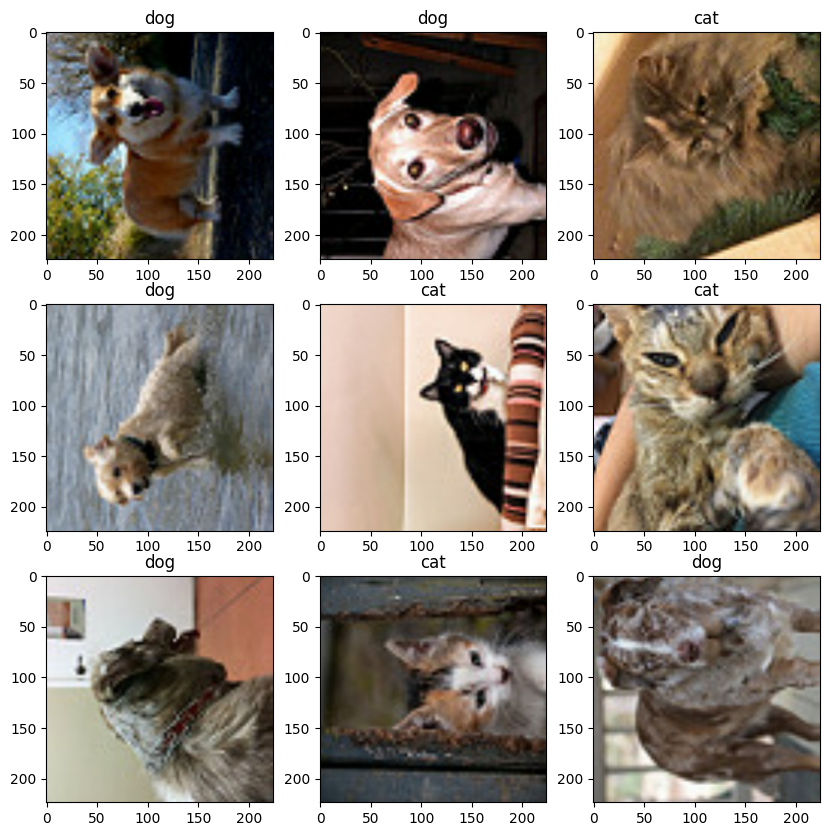

In [10]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [ ]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層の作成
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層、引数には入力層を指定

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3), #入力層で入力される画像のサイズを指定
    input_tensor=l_layer, #入力層を指定します。今回は、入力層と正規化する層を結合したもの（l_layer）を指定
    include_top=False, #出力層を含めるかどうかを指定します。今回は、出力層を自分で作成するため、False を指定
    weights="imagenet", #この引数は簡単に言うと、学習済みモデルとして利用するかの指定
    pooling='avg' #プーリング層をどのように用意するかについて指定,avg は、平均値を計算する手法
)
base_model.trainable = False #作成した MobileNetV2 のモデル全体で学習可能にするかを指定

入力層 -> 正規化する層 -> 学習済みのMobileNetV2モデル という並びのモデルが作成されます。このモデルは base_model という変数に格納

In [ ]:
# Dense層を追加する,出力層の作成、出力層の作成には tf.keras.layers.Dense() を使います
output_layer = tf.keras.layers.Dense(1, activation='sigmoid') #引数の1は,モデルから出される答が2値分類を行なうため1を指定（catかdogのみ出力される）、activation には、「活性化関数」と呼ばれるものを指定

In [13]:
# base_modelに先ほどのDense層を追加したモデルを作成する、モデルや層の結合には tf.keras.Sequential() を使います
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [15]:
# modelをcompileする
model.compile(optimizer="adam", #optimizer:最適化手法と呼ばれる、モデルがどのように計算するかの手法を指定,今回は、adam という最適化手法を指定
              loss='binary_crossentropy', #loss:損失関数と呼ばれる、モデルの出力と正解の差を計算する関数を指定,2値分類の際に有効な binary_crossentropy という関数名を指定
              metrics=["accuracy"]) #metrics：評価関数と呼ばれる、どのようにモデルを評価するかをリスト形式で指定,今回は、正解率（accuracy）のみを指定

In [16]:
# modelに学習させる,完成したモデルが持つ fit() を実行し、train_dataset の内容を学習
model.fit(train_dataset, epochs=20) #epochs はデータセットの学習回数

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - accuracy: 0.8222 - loss: 0.4062
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - accuracy: 0.9256 - loss: 0.2138
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - accuracy: 0.9461 - loss: 0.1644
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.9633 - loss: 0.1351
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.9667 - loss: 0.1165
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.9700 - loss: 0.1036
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.9806 - loss: 0.0876
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 186ms/step - accuracy: 0.9828 - loss: 0.0782
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.9856 - loss: 0.0704
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - accuracy: 0.9867 - loss: 0.0636
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.9883 - loss: 0.0581
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12

In [17]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step


In [18]:
# 分類した結果を確認する
pred_data

array([[1.2969578e-04],
       [4.8854633e-04],
       [6.0095714e-05],
       [1.1019548e-03],
       [9.3642727e-04],
       [3.4773076e-04],
       [5.5826682e-04],
       [6.3299679e-04],
       [2.7492977e-05],
       [8.9672831e-04],
       [6.0560844e-05],
       [3.9069182e-03],
       [5.5194409e-03],
       [6.1368948e-04],
       [6.7724774e-05],
       [5.7570055e-06],
       [9.4643663e-05],
       [9.5105561e-04],
       [8.3813360e-03],
       [3.6954929e-03],
       [1.1634838e-02],
       [1.4055339e-01],
       [2.2828740e-03],
       [9.5635914e-04],
       [3.4175053e-01],
       [3.4320932e-03],
       [2.2738806e-03],
       [8.8354450e-04],
       [1.5784845e-02],
       [5.1474787e-04],
       [1.1580724e-03],
       [8.5912406e-01],
       [3.6174894e-04],
       [1.1601483e-03],
       [4.4533699e-03],
       [9.3681592e-01],
       [8.9568440e-03],
       [1.9740090e-03],
       [2.8070493e-02],
       [4.6446206e-04],
       [7.2099321e-04],
       [1.083440

In [19]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.9600 - loss: 0.0833


[0.08329352736473083, 0.9599999785423279]